## Q4 Climate Index Calculation: 
Climate Drought Analysis Report Using SPI-6

## Data Understanding and Preprocessing 
##Data import, columns check, nulls, data types and Libraries import

In [24]:
# Load the dataset
df = pd.read_csv("WEATHER_REPORTS.CSV")


,YEAR,MONTH,DAY,MERRA-2 Temperature at 2 Meters (C),MERRA-2 Temperature at 2 Meters Range (C),MERRA-2 Temperature at 2 Meters Maximum (C),MERRA-2 Temperature at 2 Meters Minimum (C),MERRA-2 Precipitation Corrected (mm/day),MERRA-2 Relative Humidity at 2 Meters (%),MERRA-2 Specific Humidity at 2 Meters (g/kg),MERRA-2 Wind Speed at 10 Meters (m/s),Latitude,Longitude
0,1990,1,1,27.65,17.71,37.23,19.51,0.0,19.00,4.03,2.42,9.406,13.462
1,1990,1,2,27.87,17.19,37.21,20.01,0.0,19.12,3.91,1.84,9.406,13.462
2,1990,1,3,27.79,17.03,37.00,19.96,0.0,15.50,3.23,2.38,9.406,13.462
3,1990,1,4,26.89,18.41,36.40,17.99,0.0,19.50,4.03,2.56,9.406,13.462
4,1990,1,5,27.76,18.21,37.14,18.94,0.0,20.50,4.39,2.50,9.406,13.462
5,1990,1,6,27.62,15.62,35.90,20.28,0.0,21.19,4.82,4.22,9.406,13.462
6,1990,1,7,27.54,15.73,35.90,20.16,0.0,18.81,4.27,5.57,9.406,13.462
7,1990,1,8,27.88,16.22,36.61,20.39,0.0,17.94,4.09,5.43,9.406,13.462
8,1990,1,9,28.14,16.01,37.20,21.19,0.0,19.44,4.76,5.79,9.406,13.462
9,1990,1,10,27.76,17.90,37.49,19.58,0.0,15.62,3.54,6.80,9.406,13.462


In [39]:

#Library imports
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import zscore


# Data Cleaning approach

In [40]:
# Column cleaning for easy refrence
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_').str.replace(r'[^\w\s]', '', regex=True)

# I'm converting to a single date time column
df['date'] = pd.to_datetime(df[['year', 'month', 'day']])
df.set_index('date', inplace=True)

# Check for non numerals and removal
df = df.dropna(subset=['merra2_precipitation_corrected_mmday'])

# Rename precipitation for referencing
df.rename(columns={'merra2_precipitation_corrected_mmday': 'precip'}, inplace=True)

## Feature Engineering
6-month rolling total of precipitation — this means for each month, we’re adding up the current and previous 5 months of rainfall.
Computes the Standardized Precipitation Index (SPI) using the Z-score:
This tells us how unusual a 6-month period's rainfall is compared to the average.
Negative values = drier than usual → possible drought.
Positive values = wetter than usual.

In [41]:

# Resample to monthly total precipitation
monthly_precip = df['precip'].resample('M').sum()

# 6-month rolling sum
rolling_6_months = monthly_precip.rolling(window=6).sum()

# Calculate SPI-6 using z-score 
spi_6 = zscore(rolling_6_months, nan_policy='omit')

# Create DataFrame with results
spi6_df = pd.DataFrame({
    'Month': rolling_6_months.index,
    '6-Month Precipitation Sum (mm)': rolling_6_months.values,
    'SPI-6': spi_6
})

C:\Users\469775\AppData\Local\Temp\ipykernel_34256\654721559.py:6: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_precip = df['precip'].resample('M').sum()


# Model Development, Algoryhms and Feature selection
This block plots the SPI-6 values over time.
It includes threshold lines to show: 0 = normal, -1 = mild drought, -1.5 = moderate drought, -2 = severe drought

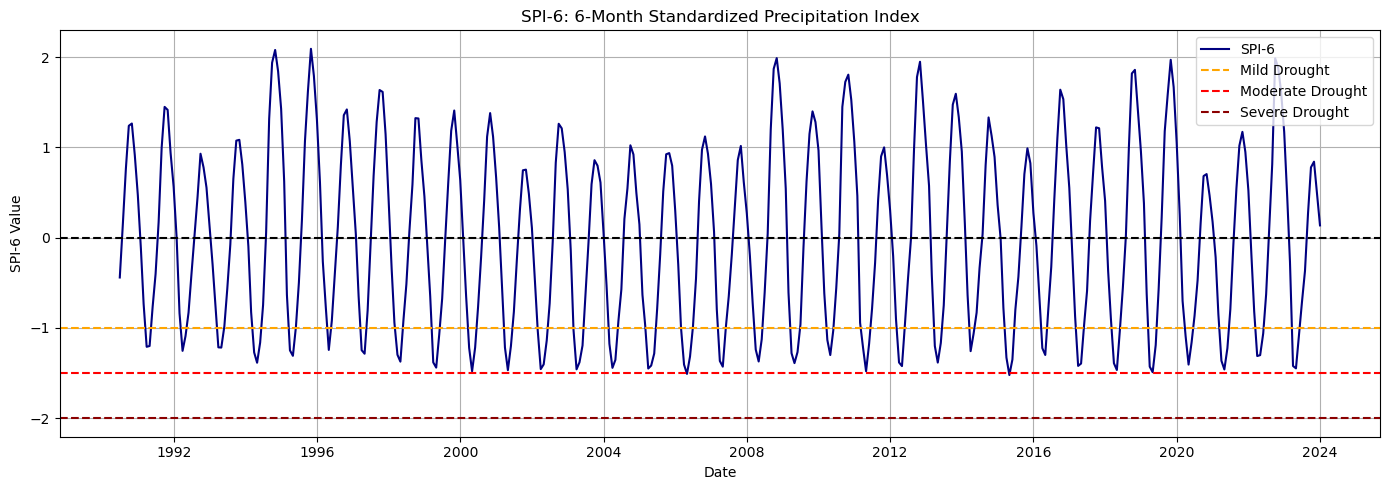

In [50]:
plt.figure(figsize=(14, 5))
plt.plot(spi6_df['Month'], spi6_df['SPI-6'], label='SPI-6', color='navy')
plt.axhline(0, color='black', linestyle='--')
plt.axhline(-1, color='orange', linestyle='--', label='Mild Drought')
plt.axhline(-1.5, color='red', linestyle='--', label='Moderate Drought')
plt.axhline(-2, color='darkred', linestyle='--', label='Severe Drought')
plt.title("SPI-6: 6-Month Standardized Precipitation Index")
plt.xlabel("Date")
plt.ylabel("SPI-6 Value")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


## Model Interpretation and Deployment 

In [49]:
print(spi6_df.head(10))

                Month  6-Month Precipitation Sum (mm)     SPI-6  \
date                                                              
1990-01-31 1990-01-31                             NaN       NaN   
1990-02-28 1990-02-28                             NaN       NaN   
1990-03-31 1990-03-31                             NaN       NaN   
1990-04-30 1990-04-30                             NaN       NaN   
1990-05-31 1990-05-31                             NaN       NaN   
1990-06-30 1990-06-30                        11547.38 -0.440489   
1990-07-31 1990-07-31                        17786.81  0.147247   
1990-08-31 1990-08-31                        24324.53  0.763081   
1990-09-30 1990-09-30                        29389.89  1.240224   
1990-10-31 1990-10-31                        29657.79  1.265459   

           Drought Category  
date                         
1990-01-31             None  
1990-02-28             None  
1990-03-31             None  
1990-04-30             None  
1990-05-31     

## Model Interpretation and Deployment 

# Ethical Considerations
- Ensured clear communication that it’s based on historical data.
-This information should be used alongside other climate indicators for risk assessment.